In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

dfHealthStudy = pd.read_csv("./Health_study_dataset.csv")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=2)
pd.set_option("display.precision", 3)

dfHStudyCopy= dfHealthStudy.copy()
np.random.seed(51) 

In [100]:

grouped_statiscics = dfHStudyCopy[["age", "weight", "height", "systolic_bp", "cholesterol"]].agg(["median", "min", "max"])
flipped_grouped = grouped_statiscics.T

flipped_grouped


,median,min,max
age,50.00,18.0,90.00
weight,73.20,33.7,114.40
height,171.35,144.4,200.40
systolic_bp,149.40,106.8,185.90
cholesterol,4.97,2.5,7.88


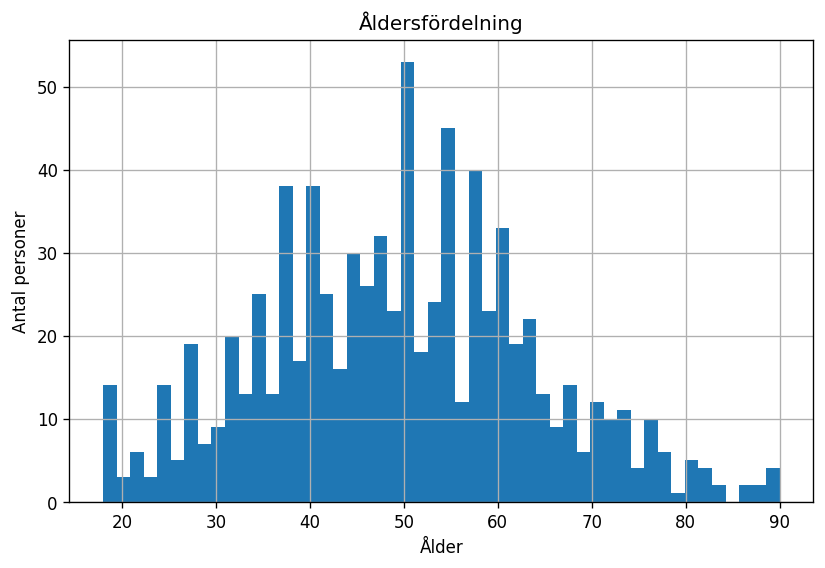

In [101]:
plt.hist(dfHStudyCopy["age"], bins=50)
plt.title("Åldersfördelning")
plt.xlabel("Ålder")
plt.ylabel("Antal personer")
plt.show()


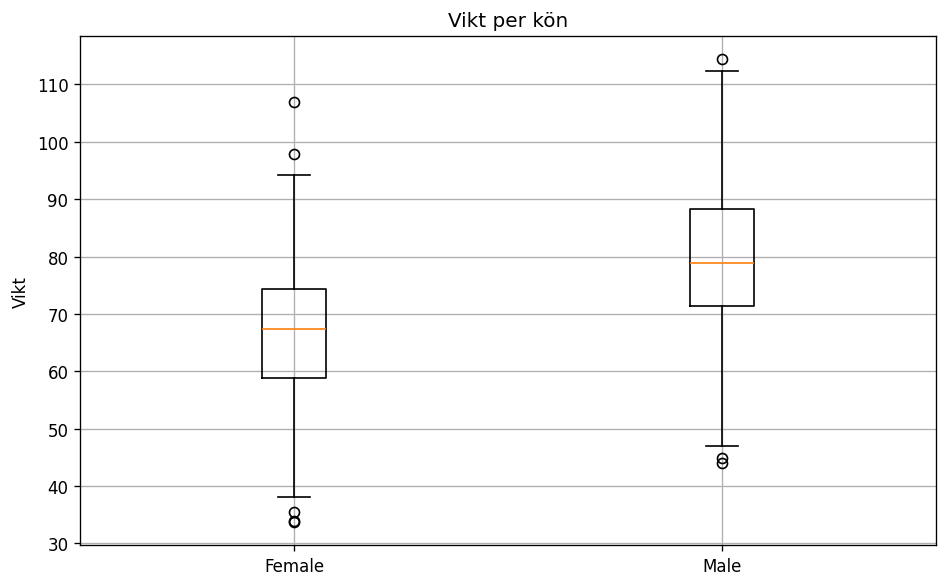

In [102]:
female_weight = dfHStudyCopy.loc[dfHStudyCopy["sex"] == "F", "weight"]
male_weight = dfHStudyCopy.loc[dfHStudyCopy["sex"] == "M", "weight"]

plt.boxplot([female_weight, male_weight], tick_labels=["Female", "Male"])
plt.title("Vikt per kön")
plt.ylabel("Vikt")
plt.tight_layout()
plt.show()

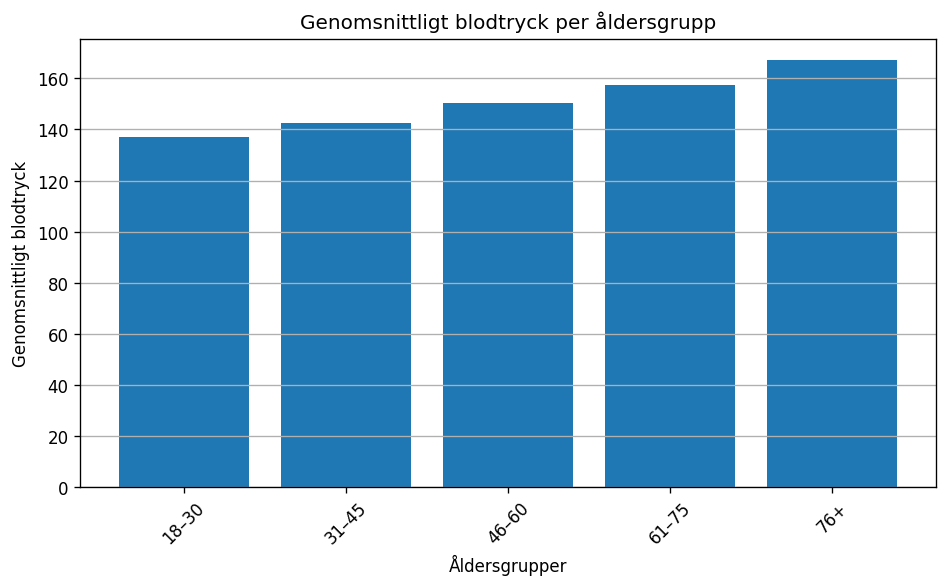

In [103]:

age_bins = [18, 30, 45, 60, 75, 120]
age_labels = ["18–30", "31–45", "46–60", "61–75", "76+"]

dfHStudyCopy["age_group"] = pd.cut(dfHStudyCopy["age"], bins=age_bins, labels=age_labels, right=False)

# Beräkna medelvärde för varje grupp
bp_means = dfHStudyCopy.groupby("age_group", observed=False)["systolic_bp"].mean()

# Rita diagrammet
plt.bar(bp_means.index.astype(str), bp_means.values)

plt.xlabel("Åldersgrupper")
plt.ylabel("Genomsnittligt blodtryck")
plt.title("Genomsnittligt blodtryck per åldersgrupp")
plt.xticks(rotation=45)
plt.grid(axis = "x")
plt.tight_layout()
plt.show()


In [104]:
actual_rate = dfHStudyCopy["disease"].mean()
simulated = np.random.binomial(n=1, p=actual_rate, size=1000)
simulated_rate = simulated.mean()

print("Verklig andel:   ", actual_rate)
print("Simulerad andel:", simulated_rate)
print("Skillnad:", simulated_rate - actual_rate)


Verklig andel:    0.05875
Simulerad andel: 0.055
Skillnad: -0.0037499999999999964


In [ ]:
data = dfHStudyCopy["systolic_bp"].values
b_range = 10000  

boot_means = []

for _ in range(b_range):
    sample = np.random.choice(data, size=len(data), replace=True)
    boot_means.append(np.mean(sample))

lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)

print(f"Bootstrap 95% KI: [{lower:.2f}, {upper:.2f}]")
print(f"Bootstrap-medel: {np.mean(boot_means):.2f}")


Bootstrap 95% KI: [148.30, 150.05]
Bootstrap-medel: 149.18


In [ ]:
smokers_bp = dfHStudyCopy[dfHStudyCopy["smoker"] == "Yes"]["systolic_bp"]
nonsmokers_bp = dfHStudyCopy[dfHStudyCopy["smoker"] == "No"]["systolic_bp"]

b_range = 5000
boot_diffs = []

for i in range(b_range):
    boot_smokers_bp = np.random.choice(smokers_bp, size=len(smokers_bp), replace=True)
    boot_nonsmokers_bp = np.random.choice(nonsmokers_bp, size=len(nonsmokers_bp), replace=True)
    boot_diffs.append(boot_smokers_bp.mean() - boot_nonsmokers_bp.mean())


mean_smokers_bp = smokers_bp.mean()
mean_nonsmokers_bp = nonsmokers_bp.mean()
difference = mean_smokers_bp - mean_nonsmokers_bp

lower = np.percentile(boot_diffs, 2.5)
upper = np.percentile(boot_diffs, 97.5)

print(f"Medelvärde rökare:, {mean_smokers_bp:.3f}")
print(f"Medelvärde icke-rökare:, {mean_nonsmokers_bp:.3f}")
print(f"Skillnad i medelvärde:, {difference:.3f}")
print(f"Bootstrap 95% CI:, ({lower:.3f}, {upper:.3f})")



Medelvärde rökare:, 149.525
Medelvärde icke-rökare:, 149.053
Skillnad i medelvärde:, 0.472
Bootstrap 95% CI:, (-1.598, 2.489)


Differensen i medelvärde mellan rökare och icke rökare är 0.472. Detta skulle tyda på att hypotesen att rökare har högre blodtryck inte kan stödjas enligt datan vi samlat. Detta i samband med bootstrap som visar ett 95% intervall på -1.541 och 2.498 som också ej stödjer hypotesen.